### Problem statement

Predicting survival of passenger travelling in RMS Titanic.

### Installing and importing of libraries

In [1]:
!pip install -q datascience                  
!pip install -q pandas-profiling              

### Upgrading libraries

In [2]:
!pip install -q --upgrade pandas-profiling

### Importing libraries

In [63]:
import pandas as pd                                                 
from pandas_profiling import ProfileReport 
import numpy as np  
import matplotlib.pyplot as plt  
from matplotlib.pylab import rcParams  
import seaborn as sns                                    
from sklearn.metrics import accuracy_score                         
from sklearn.metrics import precision_score                         
from sklearn.metrics import recall_score                            
from sklearn.metrics import precision_recall_curve                  
from sklearn.metrics import confusion_matrix                        
from sklearn.metrics import f1_score                                 
from sklearn.metrics import roc_curve 
from sklearn.model_selection import train_test_split                    
from sklearn.linear_model import LogisticRegression 
import warnings                                                   
warnings.filterwarnings("ignore")  

### Data Acquisition and description

In [5]:
titanic_data = pd.read_csv(filepath_or_buffer="D:\\books_library\\Data science\\insaid course\\Machine learning foundation\\Logistic regression\\train.csv")
titanic_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Data Information

In [6]:
titanic_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
titanic_data.shape

(891, 12)

In [8]:
titanic_data.ndim

2

In [9]:
titanic_data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [10]:
titanic_data.skew()

PassengerId    0.000000
Survived       0.478523
Pclass        -0.630548
Age            0.389108
SibSp          3.695352
Parch          2.749117
Fare           4.787317
dtype: float64

## Data Pre-Processing

In [11]:
profile = ProfileReport(df=titanic_data)
profile.to_file(output_file='pre_profile_titanic.html')
print('Accomplished')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Accomplished


### Identification of Missing Data

In [12]:
missing_df = pd.DataFrame(index = titanic_data.columns)
missing_df['Null Frequency'] = titanic_data.isnull().sum().values
missing_df['Null Percentage'] = np.round((titanic_data.isnull().sum().values/titanic_data.shape[0])*100,4)
missing_df['Zero Frequency'] = titanic_data[titanic_data==0].count().values
missing_df['Zero Percentage'] = np.round(titanic_data[titanic_data==0].count().values/titanic_data.shape[0]*100,4)
missing_df.transpose()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
Null Frequency,0.0,0.0000,0.0,0.0,0.0,177.0000,0.0000,0.0000,0.0,0.0000,687.0000,2.0000
Null Percentage,0.0,0.0000,0.0,0.0,0.0,19.8653,0.0000,0.0000,0.0,0.0000,77.1044,0.2245
Zero Frequency,0.0,549.0000,0.0,0.0,0.0,0.0000,608.0000,678.0000,0.0,15.0000,0.0000,0.0000
Zero Percentage,0.0,61.6162,0.0,0.0,0.0,0.0000,68.2379,76.0943,0.0,1.6835,0.0000,0.0000


In [13]:
titanic_data['Fare'].isnull().any()

False

In [14]:
median_age = titanic_data['Age'].median(skipna=True)
titanic_data['Age'].fillna(median_age,inplace=True)
titanic_data['Embarked'] = titanic_data['Embarked'].fillna(titanic_data['Embarked'].mode()[0])


In [15]:
titanic_data['Embarked'].mode()

0    S
Name: Embarked, dtype: object

In [16]:
titanic_data.drop(['PassengerId','Cabin'],axis=1,inplace=True)

## Feature Engineering

In [17]:
titanic_data['Familysize'] = titanic_data['SibSp'] + titanic_data['Parch'] +1 

## Exploratory Data Analysis

1. What is the frequency of proportion and survival?

In [18]:
titanic_data['Survived'].value_counts()

0    549
1    342
Name: Survived, dtype: int64

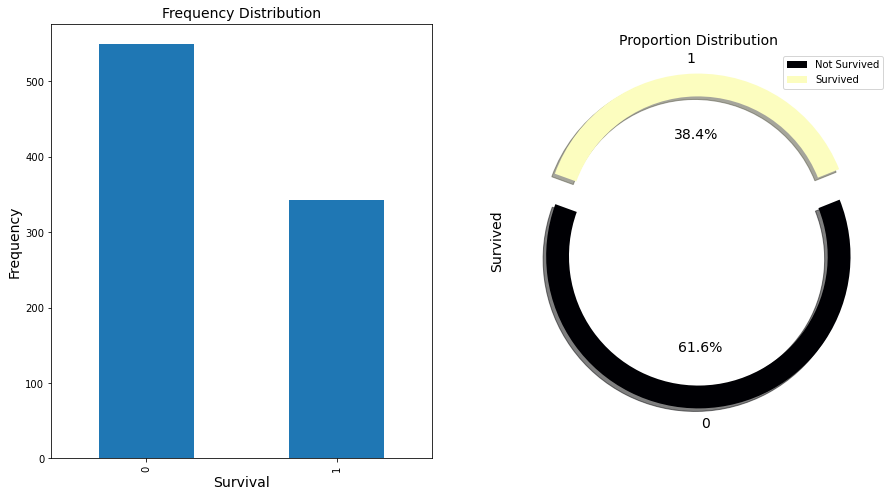

In [19]:
paper = plt.figure(figsize =[15,8])
plt.subplot(1,2,1)
titanic_data['Survived'].value_counts().plot.bar()
plt.xlabel(xlabel = 'Survival', size = 14)
plt.ylabel(ylabel = 'Frequency', size = 14)
plt.title(label = 'Frequency Distribution', size = 14)

plt.subplot(1,2,2)
space = np.ones(2)/10
titanic_data['Survived'].value_counts().plot(kind='pie',explode=space,fontsize=14,shadow=True,cmap='magma',wedgeprops=dict(width=0.15),startangle=160,autopct ='%3.1f%%')
plt.ylabel(ylabel = 'Survived', size = 14)
plt.legend(labels = ['Not Survived', 'Survived'])
plt.title(label = 'Proportion Distribution', size = 14)
plt.show()

2. Is there any association between Age and Survival?

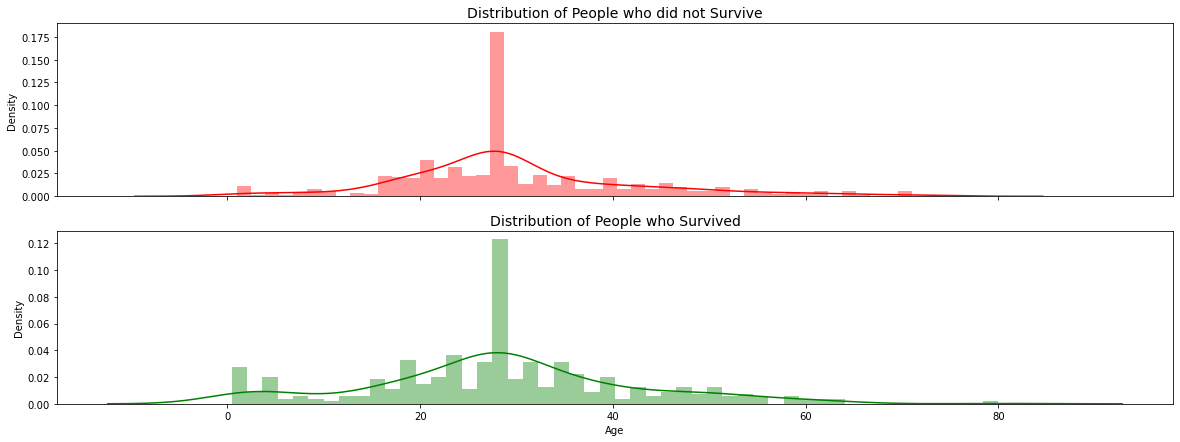

In [20]:
not_survived = titanic_data['Age'][titanic_data['Survived']==0]
survived = titanic_data['Age'][titanic_data['Survived']==1]
fig,(ax1,ax2) = plt.subplots(nrows= 2,ncols=1,sharex=True,figsize=(20,7))
sns.distplot(a=not_survived,bins=50,color='red',ax=ax1)
ax1.set_title(label = 'Distribution of People who did not Survive', size = 14)
sns.distplot(a=survived,bins=50,color='green',ax=ax2)
ax2.set_title(label = 'Distribution of People who Survived', size = 14)
plt.show()

3. Is there any relation between Survived and PClass?

In [21]:
titanic_data['Pclass'].value_counts()

3    491
1    216
2    184
Name: Pclass, dtype: int64

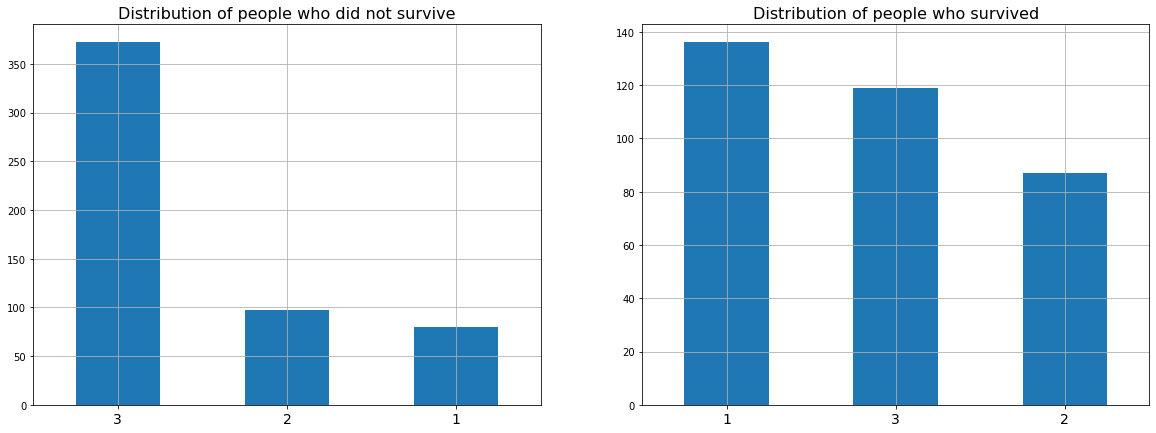

In [22]:
not_survived = titanic_data['Pclass'][titanic_data['Survived']==0].value_counts()
survived = titanic_data['Pclass'][titanic_data['Survived']==1].value_counts()
paper = plt.figure(figsize=[20,7])
ax1 = plt.subplot(1,2,1)
not_survived.plot.bar(ax=ax1)
ax1.set_title("Distribution of people who did not survive",size=16)
ax1.grid()
plt.xticks(rotation=360,size=14)
ax2 = plt.subplot(1,2,2)
survived.plot.bar(ax=ax2)
ax2.set_title("Distribution of people who survived",size=16)
plt.xticks(rotation=360,size=14)
ax2.grid()
plt.show()

In [23]:
not_survived

3    372
2     97
1     80
Name: Pclass, dtype: int64

In [24]:
survived

1    136
3    119
2     87
Name: Pclass, dtype: int64

4.Is there any relation between Survived and sex?

In [25]:
titanic_data['Sex'][titanic_data['Survived']==0].value_counts()

male      468
female     81
Name: Sex, dtype: int64

In [26]:
titanic_data['Sex'][titanic_data['Survived']==1].value_counts()

female    233
male      109
Name: Sex, dtype: int64

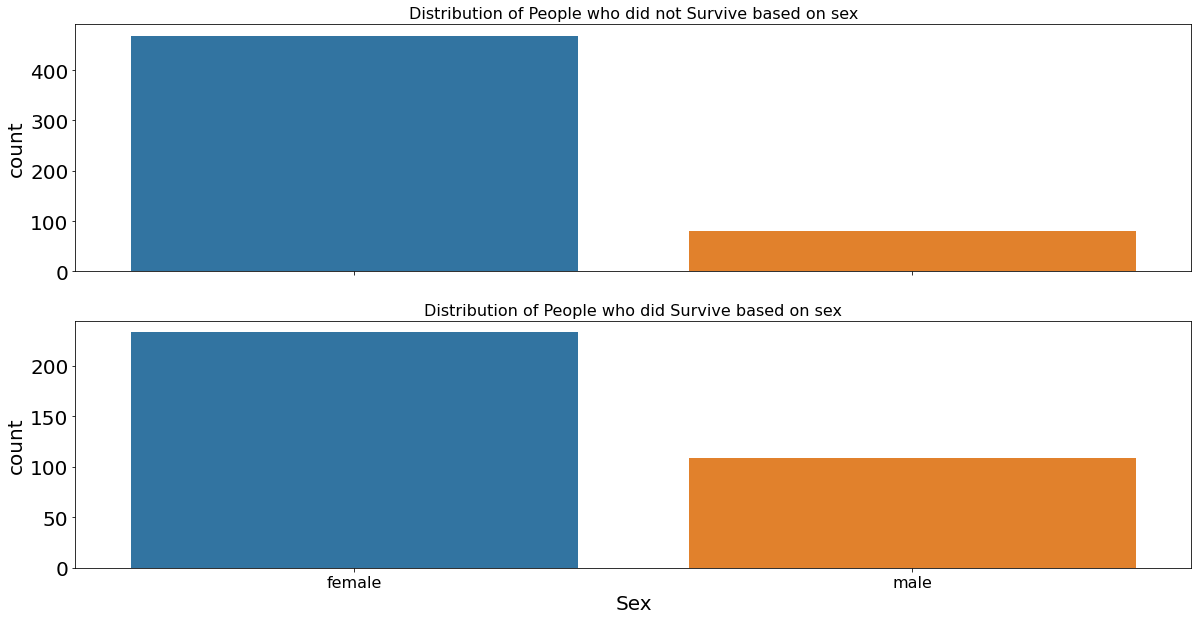

In [27]:
plt.rcParams.update({'font.size': 20})
not_surv = titanic_data['Sex'][titanic_data['Survived']==0]
surv = titanic_data['Sex'][titanic_data['Survived']==1]
fig, (ax1, ax2) = plt.subplots(nrows = 2, ncols = 1, sharex = True, figsize = (20, 10))
sns.countplot(not_surv,ax=ax1)
ax1.set_title(label = 'Distribution of People who did not Survive based on sex', size = 16)
ax1.set_xlabel(xlabel = '')
sns.countplot(surv,ax=ax2)
ax2.set_title(label = 'Distribution of People who did Survive based on sex', size = 16)
plt.xticks(size=16)
plt.show()

chi-square test between survived and pclass and Sex

In [28]:
from scipy.stats.contingency import chi2_contingency

In [29]:
def chi_sq(var1,var2): 
  crosstab = pd.crosstab(var1,var2)
  _,p,_,_ = chi2_contingency(crosstab)
  if p < 0.05:
    print(f"The relationship is strong , {round(p,2)}")
  else:
    print(f"The relationship is weak , {round(p,2)}") 
  return crosstab

In [30]:
titanic_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    int64  
 1   Pclass      891 non-null    int64  
 2   Name        891 non-null    object 
 3   Sex         891 non-null    object 
 4   Age         891 non-null    float64
 5   SibSp       891 non-null    int64  
 6   Parch       891 non-null    int64  
 7   Ticket      891 non-null    object 
 8   Fare        891 non-null    float64
 9   Embarked    891 non-null    object 
 10  Familysize  891 non-null    int64  
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


In [31]:
chi_sq(titanic_data['Pclass'],titanic_data['Survived'])

The relationship is strong , 0.0


Survived,0,1
Pclass,,
1,80,136
2,97,87
3,372,119


In [32]:
chi_sq(titanic_data['Sex'],titanic_data['Survived'])

The relationship is strong , 0.0


Survived,0,1
Sex,,
female,81,233
male,468,109


5 . is there any relation between fare and Pclass?
  

In [33]:
titanic_data.groupby(['Pclass'])['Fare'].describe()

,count,mean,std,min,25%,50%,75%,max
Pclass,,,,,,,,
1,216.0,84.154687,78.380373,0.0,30.92395,60.2875,93.5,512.3292
2,184.0,20.662183,13.417399,0.0,13.00000,14.2500,26.0,73.5000
3,491.0,13.675550,11.778142,0.0,7.75000,8.0500,15.5,69.5500


## Post Data Processing and Feature Selection

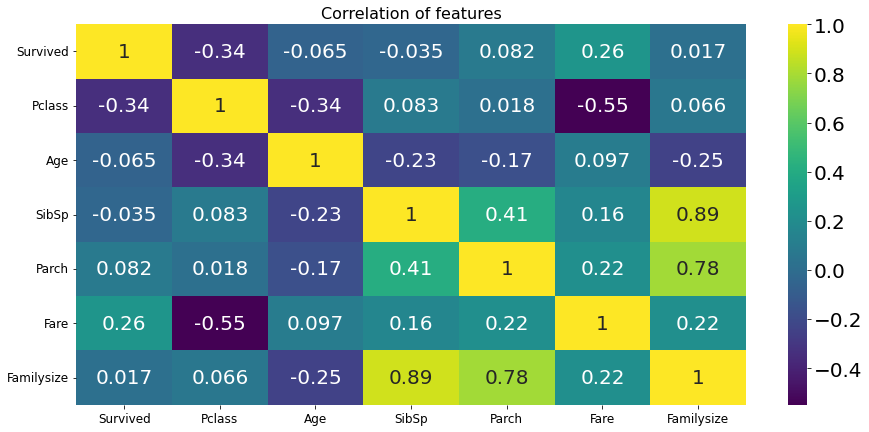

In [34]:
tit_corr = titanic_data.corr()
paper = plt.figure(figsize=[15,7])
sns.heatmap(data = tit_corr,cmap='viridis',annot = True)
plt.xticks(size=12)
plt.yticks(size=12)
plt.title(label='Correlation of features',size=16)
plt.show()

FamilySize is made from Parch and SibSb only therefore high positive corelation among them , so dropping the Parch and SibSb for redundancy issues

We are dropping Ticket,Name,Parch and SibSp columns

In [35]:
titanic_data.drop(labels = ['Ticket','Name','Parch','SibSp'],axis=1,inplace=True)

In [36]:
titanic_data.head()

,Survived,Pclass,Sex,Age,Fare,Embarked,Familysize
0,0,3,male,22.0,7.2500,S,2
1,1,1,female,38.0,71.2833,C,2
2,1,3,female,26.0,7.9250,S,1
3,1,1,female,35.0,53.1000,S,2
4,0,3,male,35.0,8.0500,S,1


In [37]:
titanic_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    int64  
 1   Pclass      891 non-null    int64  
 2   Sex         891 non-null    object 
 3   Age         891 non-null    float64
 4   Fare        891 non-null    float64
 5   Embarked    891 non-null    object 
 6   Familysize  891 non-null    int64  
dtypes: float64(2), int64(3), object(2)
memory usage: 48.9+ KB


## Post Profiling Report

In [38]:
profile = ProfileReport(df=titanic_data)
profile.to_file(output_file='post_profile_titanic.html')
print('Accomplished')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Accomplished


In [39]:
titanic_data.skew()

Survived      0.478523
Pclass       -0.630548
Age           0.510245
Fare          4.787317
Familysize    2.727441
dtype: float64

## Encoding Categorical Features:

In [40]:
titanic_data['Pclass'] = titanic_data['Pclass'].astype(dtype='object')

In [41]:
titanic_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    int64  
 1   Pclass      891 non-null    object 
 2   Sex         891 non-null    object 
 3   Age         891 non-null    float64
 4   Fare        891 non-null    float64
 5   Embarked    891 non-null    object 
 6   Familysize  891 non-null    int64  
dtypes: float64(2), int64(2), object(3)
memory usage: 48.9+ KB


In [42]:
encoded_data = pd.get_dummies(titanic_data)
encoded_data.head()

,Survived,Age,Fare,Familysize,Pclass_1,Pclass_2,Pclass_3,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,0,22.0,7.2500,2,0,0,1,0,1,0,0,1
1,1,38.0,71.2833,2,1,0,0,1,0,1,0,0
2,1,26.0,7.9250,1,0,0,1,1,0,0,0,1
3,1,35.0,53.1000,2,1,0,0,1,0,0,0,1
4,0,35.0,8.0500,1,0,0,1,0,1,0,0,1


### Data Preparation

In [43]:
x = encoded_data.drop("Survived",axis=1)
y = encoded_data['Survived']

In [44]:
x.head()

,Age,Fare,Familysize,Pclass_1,Pclass_2,Pclass_3,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,22.0,7.2500,2,0,0,1,0,1,0,0,1
1,38.0,71.2833,2,1,0,0,1,0,1,0,0
2,26.0,7.9250,1,0,0,1,1,0,0,0,1
3,35.0,53.1000,2,1,0,0,1,0,0,0,1
4,35.0,8.0500,1,0,0,1,0,1,0,0,1


In [45]:
y.head()

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

In [46]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.1,random_state=42,stratify=y)
print(f'training data shape :{x_train.shape},{y_train.shape}')
print(f'testing data shape :{x_test.shape},{y_test.shape}')

training data shape :(801, 11),(801,)
testing data shape :(90, 11),(90,)


## Model Development and Evaluation

In [47]:
logreg =  LogisticRegression()
logreg.fit(x_train,y_train)

LogisticRegression()

In [48]:
logreg.classes_

array([0, 1], dtype=int64)

In [49]:
logreg.coef_

array([[-0.04055589,  0.00356112, -0.19836244,  1.17210076,  0.34764188,
        -0.825165  ,  1.67384282, -0.97926518,  0.36358611,  0.34256929,
        -0.01157776]])

In [50]:
logreg.intercept_

array([0.87201285])

### Using Trained Model for Prediction:

In [51]:
# Predicting the train data
y_pred_train = logreg.predict(x_train)

# Predicting the test data
y_pred_test = logreg.predict(x_test)

## Logistic Regression Evaluation:

In [64]:
cm = pd.DataFrame(confusion_matrix(y_train,y_pred_train))
cm.index = ['Actual Died','Actual Survived']
cm.columns = ['Predicted Died','Predicted Survived']
print(cm)

                 Predicted Died  Predicted Survived
Actual Died                 431                  63
Actual Survived              92                 215


In [65]:
cm1 = pd.DataFrame(confusion_matrix(y_test,y_pred_test))
cm1.index = ['Actual Died','Actual Survived']
cm1.columns = ['Predicted Died','Predicted Survived']
print(cm1)

                 Predicted Died  Predicted Survived
Actual Died                  45                  10
Actual Survived              11                  24


Checking Accuracy

In [67]:
print('Accuracy score for train data is:', accuracy_score(y_train,y_pred_train))

Accuracy score for train data is: 0.8064918851435705


In [68]:
print('Accuracy score for test data is:', accuracy_score(y_test,y_pred_test))

Accuracy score for test data is: 0.7666666666666667
